# Food Truck Data Pipeline — Analysis

**What this is:** a database-design project from BUS 315 (ER model + 10 hand-written SQL queries),
rebuilt as a small automated data pipeline: synthetic data generation → load →
validation → analytics views. This notebook runs the analytics layer live
against the pipeline's output and visualizes the results.

**Stack:** Python + Faker (synthetic data generation), SQLite (warehouse),
SQL views (the transform/analytics layer), pandas/matplotlib (this notebook's
loading and charting layer only — the analysis itself lives in SQL).

**Repo structure:**
- `sql/schema.sql` — table definitions, keys, relationships
- `scripts/generate_data.py` — synthetic source data generation
- `scripts/load_and_transform.py` — loads data, builds analytics views
- `scripts/data_quality_checks.py` — validates the load (row counts, nulls, FKs, PKs)
- `scripts/run_pipeline.py` — runs all of the above in order
- `docs/original_queries.sql` — the original 10 business-question queries
- this notebook — runs the analytics views and visualizes results


## 1. Connect to the database

Run `python3 scripts/run_pipeline.py` from the repo root first — it generates
synthetic data, loads it into `foodtruck.db` (written to the repo root), builds
the analytics views, and validates the result. That pipeline is deliberately
separate from this notebook — the generation, loading, and validation logic is
all plain Python/SQL, reviewable and runnable independently of any notebook.
This notebook (in `notebook/`) connects to `../foodtruck.db`, so run it from
inside the `notebook/` folder, or launch Jupyter from the repo root and open
it from there.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("../foodtruck.db")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 2. Pipeline design decisions

A few judgment calls made in building the pipeline, worth stating explicitly:

- **Synthetic data generation is seeded** (`Faker.seed(42)`, `random.seed(42)`), so
  every run produces identical data — this makes bugs reproducible instead of
  intermittent.
- **Data is generated in dependency order** (trucks → employees → customers → menu
  items → orders → order lines → inventory), since later tables reference earlier
  ones by foreign key.
- **The original ad hoc queries became permanent SQL views** rather than one-off
  scripts — a view re-runs its query every time it's referenced, so results are
  always current instead of a snapshot from whenever a query happened to run.
- **Data quality checks use loose row-count ranges** (e.g. employee: 90–110) rather
  than exact counts, to catch a load that silently failed or truncated without
  hardcoding brittle fixture sizes.

## 3. Data model

Seven tables: `truck`, `employee` (with a recursive manager hierarchy via
`boss_id`), `customer`, `menu_item`, `order`, `order_has_menu_item` (the
many-to-many associative table between orders and menu items), and `inventory`.
Full column-level detail is in `sql/schema.sql`.

## 4. Data quality check

Before trusting any of the analysis below, confirm the loaded data actually
passes validation. This reruns the same row-count / null / referential-integrity
checks the pipeline runs automatically after every load.

In [2]:
import subprocess, sys
result = subprocess.run(
    [sys.executable, "../scripts/data_quality_checks.py"],
    capture_output=True, text=True, cwd="."
)
print(result.stdout[-600:])

ustomer_id -> customer.customer_id
  OK   order_has_menu_item.order_id -> order.order_id
  OK   order_has_menu_item.menu_item_id -> menu_item.menu_item_id
  OK   inventory.truck_id -> truck.truck_id
  OK   inventory.menu_item_id -> menu_item.menu_item_id

[4/4] Primary key uniqueness checks
  OK   truck.truck_id
  OK   employee.employee_id
  OK   customer.customer_id
  OK   menu_item.menu_item_id
  OK   order.order_id
  OK   inventory.item_id
  OK   order_has_menu_item(order_id, menu_item_id)

RESULT: all data quality checks passed.



## 5. Revenue by truck

Reproduces `vw_revenue_by_truck` — total orders and revenue per truck, joining
customers to their home truck, then to orders and order line items.

In [3]:
revenue = pd.read_sql('''
    SELECT restaurant_name AS truck, order_count, total_revenue
    FROM vw_revenue_by_truck
    ORDER BY total_revenue DESC
''', conn)
revenue

,truck,order_count,total_revenue
0,Mac Mart,26,1296.50
1,Lex Mex,25,824.00
2,Oink-Moo BBQ,25,777.50
3,Mr. H's Donuts,24,310.25


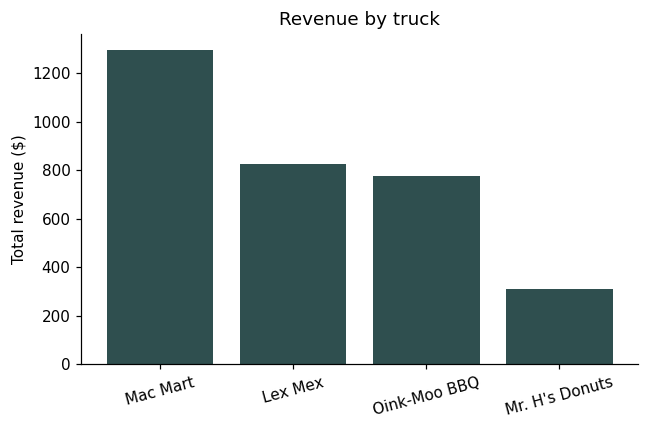

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(revenue["truck"], revenue["total_revenue"], color="#2F4F4F")
ax.set_ylabel("Total revenue ($)")
ax.set_title("Revenue by truck")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 6. Most popular menu items per truck

Reproduces `vw_top_menu_items_by_truck` — this was originally business question
#3 in the class project (hand-written query using `SUM` + `GROUP BY`), now a
permanent view. Showing the top 3 items per truck by quantity ordered.

In [5]:
top_items = pd.read_sql('''
    SELECT restaurant_name AS truck, menu_item_name AS item, total_quantity_ordered AS qty
    FROM vw_top_menu_items_by_truck
''', conn)

top3 = (top_items.sort_values(["truck", "qty"], ascending=[True, False])
                  .groupby("truck").head(3).reset_index(drop=True))
top3

,truck,item,qty
0,Lex Mex,Nachos,30
1,Lex Mex,Tacos al Pastor,24
2,Lex Mex,Mexican Street Corn,24
3,Mac Mart,Classic Mac & Cheese,34
4,Mac Mart,BBQ Mac & Cheese,30
5,Mac Mart,Truffle Mac & Cheese,28
6,Mr. H's Donuts,Cinnamon Sugar Donut,21
7,Mr. H's Donuts,Lemon Glazed Donut,19
8,Mr. H's Donuts,Glazed Donut,18
9,Oink-Moo BBQ,Sweet Potato Fries,22


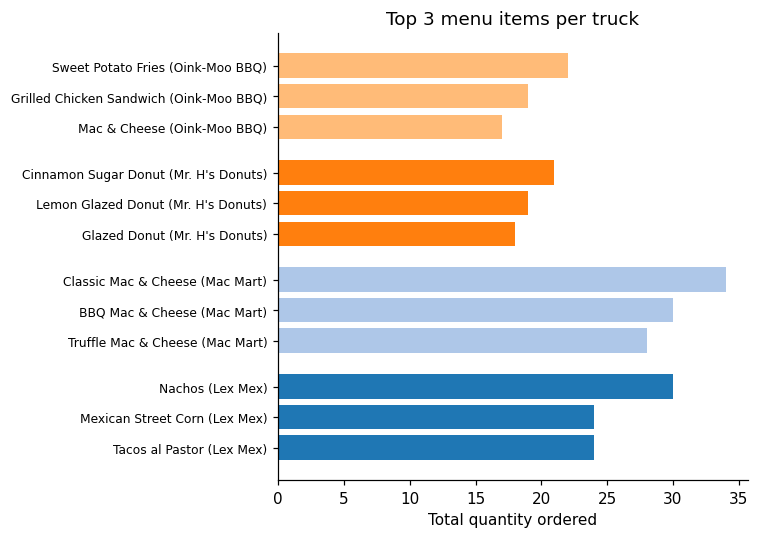

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = plt.cm.tab20.colors
trucks = top3["truck"].unique()
y_pos = 0
yticks, ylabels = [], []
for i, truck in enumerate(trucks):
    sub = top3[top3["truck"] == truck].sort_values("qty")
    for _, row in sub.iterrows():
        ax.barh(y_pos, row["qty"], color=colors[i % len(colors)])
        yticks.append(y_pos)
        ylabels.append(f'{row["item"]} ({truck})')
        y_pos += 1
    y_pos += 0.5
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, fontsize=8)
ax.set_xlabel("Total quantity ordered")
ax.set_title("Top 3 menu items per truck")
plt.tight_layout()
plt.show()

## 7. Inventory expiring within 30 days

Reproduces `vw_inventory_expiring_30d` — originally business question #7, used to
flag trucks that need to prioritize using or reordering stock soon.

In [7]:
expiring = pd.read_sql('SELECT restaurant_name AS truck, expiring_item_count FROM vw_inventory_expiring_30d ORDER BY expiring_item_count DESC', conn)
expiring

,truck,expiring_item_count
0,Lex Mex,2
1,Oink-Moo BBQ,1


## 8. Pay-structure anomalies

Reproduces `vw_employees_paid_more_than_boss` — originally business question #8,
flagging any employee earning more than their direct manager, grouped by truck.
This uses a **self-join** on the employee table (`employee.boss_id -> employee.employee_id`).

In [8]:
pay_anomalies = pd.read_sql('SELECT * FROM vw_employees_paid_more_than_boss', conn)
if pay_anomalies.empty:
    print("No pay anomalies found in this dataset.")
else:
    pay_anomalies

No pay anomalies found in this dataset.


## 9. Loyalty program enrollment

Originally business question #2 (`LEFT JOIN ... WHERE loyaltyNumber IS NULL`) —
what share of customers at each truck haven't enrolled in the loyalty program.
This isn't (yet) a permanent view, run directly here as an example of extending
the analytics layer beyond the current four views.

In [9]:
loyalty = pd.read_sql('''
    SELECT t.restaurant_name AS truck,
           SUM(CASE WHEN c.loyalty_number IS NULL THEN 1 ELSE 0 END) AS not_enrolled,
           COUNT(*) AS total_customers
    FROM customer c
    JOIN truck t ON t.truck_id = c.truck_id
    GROUP BY t.restaurant_name
''', conn)
loyalty["pct_not_enrolled"] = (loyalty["not_enrolled"] / loyalty["total_customers"] * 100).round(1)
loyalty

,truck,not_enrolled,total_customers,pct_not_enrolled
0,Lex Mex,5,12,41.7
1,Mac Mart,7,20,35.0
2,Mr. H's Donuts,2,13,15.4
3,Oink-Moo BBQ,3,15,20.0


## 10. Summary

- All data quality checks pass on the generated dataset (row counts, null rates,
  referential integrity, primary key uniqueness).
- Mac Mart leads on both order volume and total revenue in this run.
- No pay-structure anomalies were found in this dataset — but the check itself is
  the point: it's a self-join that runs automatically as part of the analytics
  layer, not a one-time manual audit.

**Next steps:** orchestrate this pipeline on a schedule (Airflow/Prefect),
replace the CSV intermediate step with `dbt` models, and run the schema against
the included Postgres Docker service instead of SQLite. See the main
[README](../README.md) for details.

In [10]:
conn.close()